# Put-Call Parity Predictor

This notebook examines the options kernel ACF analysis — how hedging flow at different DTE timescales correlates with subsequent equity returns.

**Key questions:**
- Does LEAPS activity predict equity returns at longer lags?
- Is there a DTE hierarchy: 0DTE → WEEKLY → MONTHLY → LEAPS?
- Do multiple tickers show the same structural pattern?

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load all kernel results
results_dir = '../results'
tickers = {}
for f in sorted(os.listdir(results_dir)):
    if f.startswith('phase5a_kernel_') and f.endswith('.json'):
        ticker = f.replace('phase5a_kernel_', '').replace('.json', '')
        with open(os.path.join(results_dir, f)) as fh:
            tickers[ticker] = json.load(fh)

print(f'Loaded kernel results for {len(tickers)} tickers: {list(tickers.keys())}')

Loaded kernel results for 7 tickers: ['AAPL', 'CHWY', 'DJT', 'GME', 'PLTR', 'SOFI', 'TSLA']


## 1. GME: Options Flow → Equity Return Correlation by DTE

In [2]:
# Build GME correlation table
gme = tickers.get('GME', {})
lags = ['T+0', 'T+1', 'T+2', 'T+5', 'T+10', 'T+20']
dte_cats = ['0DTE', 'WEEKLY', 'MONTHLY', 'LEAPS']

rows = []
for dte in dte_cats:
    row = {'DTE Category': dte}
    for lag in lags:
        row[lag] = gme.get(dte, {}).get(lag, None)
    row['Peak Lag'] = gme.get(dte, {}).get('peak_lag', None)
    row['Peak Corr'] = gme.get(dte, {}).get('peak_corr', None)
    rows.append(row)

df = pd.DataFrame(rows).set_index('DTE Category')
print('GME: Options Flow → Equity Return Correlation')
print('=' * 75)
print(df.to_string())

print(f"\n► Key finding: LEAPS peak correlation ({gme.get('LEAPS', {}).get('peak_corr', 'N/A')}) "
      f"occurs at T+{gme.get('LEAPS', {}).get('peak_lag', 'N/A')}, "
      f"while 0DTE peaks at T+{gme.get('0DTE', {}).get('peak_lag', 'N/A')}")

GME: Options Flow → Equity Return Correlation
                 T+0     T+1     T+2     T+5    T+10    T+20  Peak Lag  Peak Corr
DTE Category                                                                     
0DTE         -0.0328 -0.0578 -0.0418 -0.0161 -0.0675 -0.0598        10    -0.0675
WEEKLY       -0.0566 -0.0646 -0.0764 -0.0612 -0.0360 -0.0714         2    -0.0764
MONTHLY      -0.0826 -0.0973 -0.0894 -0.0972 -0.0644 -0.0363         1    -0.0973
LEAPS        -0.0623 -0.0710 -0.0841 -0.1232 -0.1354 -0.2011        20    -0.2011

► Key finding: LEAPS peak correlation (-0.2011) occurs at T+20, while 0DTE peaks at T+10


## 2. Correlation Heatmap: DTE × Lag

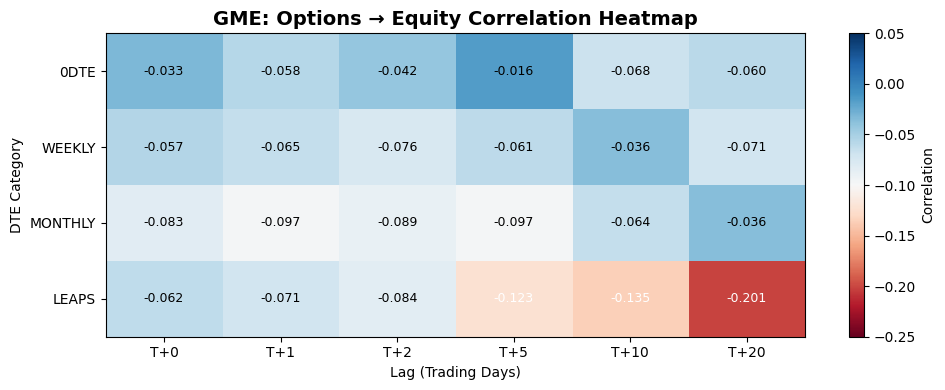

In [3]:
# Heatmap
heat_data = []
for dte in dte_cats:
    heat_data.append([gme.get(dte, {}).get(lag, 0) for lag in lags])

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(heat_data, cmap='RdBu', aspect='auto', vmin=-0.25, vmax=0.05)
ax.set_xticks(range(len(lags)))
ax.set_xticklabels(lags)
ax.set_yticks(range(len(dte_cats)))
ax.set_yticklabels(dte_cats)
ax.set_title('GME: Options → Equity Correlation Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Lag (Trading Days)')
ax.set_ylabel('DTE Category')

# Annotate cells
for i in range(len(dte_cats)):
    for j in range(len(lags)):
        val = heat_data[i][j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', 
                color='white' if abs(val) > 0.1 else 'black', fontsize=9)

plt.colorbar(im, label='Correlation')
plt.tight_layout()
plt.show()

## 3. Cross-Ticker Comparison: Peak Lag by DTE

In [4]:
# Compare peak lags across all tickers
rows = []
for ticker, data in sorted(tickers.items()):
    row = {'Ticker': ticker}
    for dte in dte_cats:
        info = data.get(dte, {})
        row[f'{dte} Peak Lag'] = info.get('peak_lag', None)
        row[f'{dte} Peak r'] = info.get('peak_corr', None)
    rows.append(row)

cross_df = pd.DataFrame(rows).set_index('Ticker')
print('Cross-Ticker: Peak Lag and Correlation by DTE Category')
print('=' * 90)
print(cross_df.to_string())

Cross-Ticker: Peak Lag and Correlation by DTE Category
        0DTE Peak Lag  0DTE Peak r  WEEKLY Peak Lag  WEEKLY Peak r  MONTHLY Peak Lag  MONTHLY Peak r  LEAPS Peak Lag  LEAPS Peak r
Ticker                                                                                                                            
AAPL                0      -0.1910               10        -0.1269                20         -0.0836               5       -0.0552
CHWY                5       0.0968                5        -0.0290                20         -0.1489               0       -0.0950
DJT                10      -0.2294               20        -0.1636                10         -0.0262              20        0.0872
GME                10      -0.0675                2        -0.0764                 1         -0.0973              20       -0.2011
PLTR               20      -0.2115                0        -0.1843                 1         -0.1896               1       -0.1308
SOFI                0      -

## 4. LEAPS Peak Lag Distribution

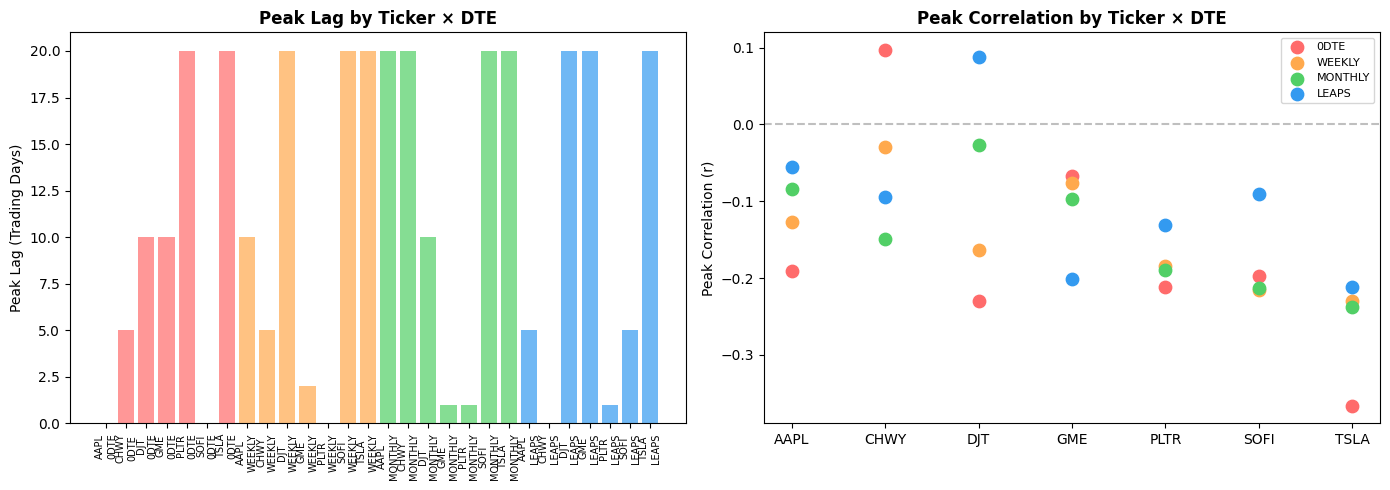


DTE Timescale Test: LEAPS wins at T+20 for 2/7 tickers


In [5]:
# Visualize that LEAPS consistently peak at longer lags
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Peak lag by category
for dte, color in zip(dte_cats, ['#ff6b6b', '#ffa94d', '#51cf66', '#339af0']):
    peak_lags = [tickers[t].get(dte, {}).get('peak_lag', 0) for t in sorted(tickers.keys())]
    axes[0].bar([f'{t}\n{dte}' for t in sorted(tickers.keys())], peak_lags, 
               color=color, alpha=0.7, label=dte)

axes[0].set_title('Peak Lag by Ticker × DTE', fontweight='bold')
axes[0].set_ylabel('Peak Lag (Trading Days)')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)

# Peak correlation by category  
for dte, color in zip(dte_cats, ['#ff6b6b', '#ffa94d', '#51cf66', '#339af0']):
    peak_corrs = [tickers[t].get(dte, {}).get('peak_corr', 0) for t in sorted(tickers.keys())]
    x = np.arange(len(tickers))
    axes[1].scatter(sorted(tickers.keys()), peak_corrs, color=color, s=80, label=dte, zorder=3)

axes[1].set_title('Peak Correlation by Ticker × DTE', fontweight='bold')
axes[1].set_ylabel('Peak Correlation (r)')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# DTE timescale test
with open('../results/q5_dte_timescale.json') as f:
    dte_test = json.load(f)
print(f"\nDTE Timescale Test: LEAPS wins at T+20 for {dte_test.get('leaps_wins_t20', 'N/A')}/{dte_test.get('total_tickers', 'N/A')} tickers")

---
*Data source: ThetaData options trades, Polygon equity trades. Analysis code in `../code/analysis/putcall_parity_predictor.py`.*